# 02 — Alpha Models (LightGBM Ensemble)

**Purpose:** Train an ensemble of LightGBM models to predict cross-sectional stock return ranks.
Each sub-model focuses on a distinct feature class to maximize ensemble diversity.

**Architecture:**
- `lgb_momentum`: trained on momentum and cross-sectional rank features only
- `lgb_volatility`: trained on volatility ratio features only
- `lgb_technical`: trained on RSI, Bollinger, MACD, ATR features only
- `lgb_combined`: trained on ALL selected features (the master model)

**Validation:** Walk-Forward with 5 folds + 10-day embargo. NO random K-Fold.

**Optimization:** Optuna (200 trials) maximizing out-of-sample Rank IC.

**Outputs:** Fitted models, SHAP values, Rank IC curve, walk-forward equity curve.

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
import json
import pickle
from copy import deepcopy

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.stats import spearmanr
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

warnings.filterwarnings('ignore')
np.random.seed(42)
pd.set_option('display.max_columns', 60)

# ── Paths ──────────────────────────────────────────────────────────────────────
WD = Path('.')

# ── Parameters ────────────────────────────────────────────────────────────────
TRAIN_YEARS   = 4      # walk-forward training window (years)
TEST_YEARS    = 1      # walk-forward test window  (years)
EMBARGO_DAYS  = 10     # trading days gap between train and test
OPTUNA_TRIALS = 200    # hyperparameter search trials per fold
N_FOLDS       = 5      # walk-forward folds
TOP_N         = 20     # stocks in long portfolio per rebalance
BOTTOM_N      = 20     # stocks in short portfolio per rebalance
REBAL_FREQ    = 5      # rebalance every N trading days
TC_BPS        = 5      # one-way transaction cost in basis points

print('✓ Imports loaded')

✓ Imports loaded


## 1 — Load Feature Panel

In [3]:
panel = pd.read_parquet(WD / 'features_panel.parquet')
panel['date'] = pd.to_datetime(panel['date'])

with open(WD / 'feature_meta.json', 'r') as f:
    meta = json.load(f)

SELECTED_FEATS = meta['selected_features']
PCA_COLS       = meta['pca_cols']
print(f'Panel: {len(panel):,} rows  |  {panel["ticker"].nunique()} tickers')
print(f'Selected features: {len(SELECTED_FEATS)}')
print(f'Date range: {panel["date"].min().date()} → {panel["date"].max().date()}')

Panel: 1,512,735 rows  |  499 tickers
Selected features: 45
Date range: 2010-01-05 → 2022-07-05


In [4]:
# ── Assign features to sub-model groups ───────────────────────────────────────
# We look for features by name pattern to assign to specialist sub-models.

momentum_patterns  = ['mom_', 'xs_rank_mom', 'mkt_dm_mom', 'ma_ratio_', 'macd']
volatility_patterns = ['vol_', 'atr', 'bb_width', 'ret_skew', 'ret_kurt', 'hl_range']
technical_patterns  = ['rsi_', 'bb_position', 'obv_', 'ret_autocorr', 'price_zscore']

def get_features_by_pattern(patterns, all_feats):
    result = []
    for feat in all_feats:
        if any(feat.startswith(p) or p in feat for p in patterns):
            result.append(feat)
    return list(dict.fromkeys(result))  # deduplicate, preserve order

MOMENTUM_FEATS   = get_features_by_pattern(momentum_patterns,  SELECTED_FEATS)
VOLATILITY_FEATS = get_features_by_pattern(volatility_patterns, SELECTED_FEATS)
TECHNICAL_FEATS  = get_features_by_pattern(technical_patterns,  SELECTED_FEATS)

# Fallback: if a group has fewer than 3 features, use all selected
if len(MOMENTUM_FEATS) < 3:   MOMENTUM_FEATS = SELECTED_FEATS
if len(VOLATILITY_FEATS) < 3: VOLATILITY_FEATS = SELECTED_FEATS
if len(TECHNICAL_FEATS) < 3:  TECHNICAL_FEATS = SELECTED_FEATS

FEATURE_GROUPS = {
    'lgb_momentum':   MOMENTUM_FEATS,
    'lgb_volatility': VOLATILITY_FEATS,
    'lgb_technical':  TECHNICAL_FEATS,
    'lgb_combined':   SELECTED_FEATS,
}
for name, feats in FEATURE_GROUPS.items():
    print(f'{name:<20}: {len(feats)} features')

lgb_momentum        : 22 features
lgb_volatility      : 16 features
lgb_technical       : 7 features
lgb_combined        : 45 features


## 2 — Walk-Forward Validation Framework

In [5]:
def generate_walk_forward_folds(
    dates: pd.DatetimeIndex,
    train_years: int,
    test_years: int,
    embargo_days: int
):
    """
    Generate (train_start, train_end, test_start, test_end) tuples.
    Embargo gap = embargo_days trading days between train_end and test_start.
    """
    unique_dates = sorted(dates.unique())
    total_days   = len(unique_dates)

    train_size = int(train_years * 252)
    test_size  = int(test_years  * 252)

    folds = []
    start = 0
    while start + train_size + embargo_days + test_size <= total_days:
        train_start = unique_dates[start]
        train_end   = unique_dates[start + train_size - 1]
        test_start  = unique_dates[start + train_size + embargo_days]
        test_end_idx = min(start + train_size + embargo_days + test_size - 1, total_days - 1)
        test_end    = unique_dates[test_end_idx]
        folds.append((train_start, train_end, test_start, test_end))
        start += test_size  # advance by one test window

    return folds


all_dates = pd.to_datetime(panel['date'].unique())
folds     = generate_walk_forward_folds(all_dates, TRAIN_YEARS, TEST_YEARS, EMBARGO_DAYS)

print(f'Walk-forward folds: {len(folds)}')
for i, (ts, te, vs, ve) in enumerate(folds, 1):
    n_train = len(panel[(panel['date'] >= ts) & (panel['date'] <= te)])
    n_test  = len(panel[(panel['date'] >= vs) & (panel['date'] <= ve)])
    print(f'  Fold {i}: train {ts.date()}→{te.date()} ({n_train:,})  test {vs.date()}→{ve.date()} ({n_test:,})')

Walk-forward folds: 8
  Fold 1: train 2010-01-05→2014-01-06 (460,844)  test 2014-01-22→2015-01-21 (120,275)
  Fold 2: train 2011-01-04→2015-01-06 (469,079)  test 2015-01-22→2016-01-21 (122,349)
  Fold 3: train 2012-01-04→2016-01-06 (477,066)  test 2016-01-22→2017-01-20 (123,215)
  Fold 4: train 2013-01-07→2017-01-05 (483,984)  test 2017-01-23→2018-01-22 (123,919)
  Fold 5: train 2014-01-07→2018-01-05 (489,568)  test 2018-01-23→2019-01-23 (124,452)
  Fold 6: train 2015-01-07→2019-01-08 (493,805)  test 2019-01-24→2020-01-23 (125,557)
  Fold 7: train 2016-01-07→2020-01-08 (497,033)  test 2020-01-24→2021-01-22 (125,748)
  Fold 8: train 2017-01-06→2021-01-07 (499,596)  test 2021-01-25→2022-01-21 (125,748)


## 3 — LightGBM with Optuna Hyperparameter Optimization

In [6]:
# ── Fixed LightGBM config (non-tunable params) ─────────────────────────────────
LGB_FIXED = {
    'objective':        'regression',
    'metric':           'mae',
    'boosting_type':    'gbdt',
    'verbosity':        -1,
    'random_state':     42,
    'n_jobs':           -1,
    'force_col_wise':   True,
}

# ── Optuna search space ────────────────────────────────────────────────────────
def optuna_objective(trial, X_train, y_train, X_val, y_val):
    """Maximize out-of-sample Rank IC."""
    params = {
        **LGB_FIXED,
        'n_estimators':      trial.suggest_int('n_estimators',     100, 2000),
        'learning_rate':     trial.suggest_float('learning_rate',  0.005, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth',        3, 12),
        'num_leaves':        trial.suggest_int('num_leaves',       15, 255),
        'min_child_samples': trial.suggest_int('min_child_samples',5, 100),
        'subsample':         trial.suggest_float('subsample',      0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha',      1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda',     1e-8, 10.0, log=True),
        'min_split_gain':    trial.suggest_float('min_split_gain', 0.0, 0.5),
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    preds = model.predict(X_val)
    ic, _ = spearmanr(preds, y_val)
    return ic  # maximize


def train_lgb_with_optuna(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val:   np.ndarray,
    y_val:   np.ndarray,
    n_trials: int = OPTUNA_TRIALS,
    model_name: str = 'lgb'
) -> lgb.LGBMRegressor:
    """Run Optuna search, return best model retrained on full train set."""
    study = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(
        lambda trial: optuna_objective(trial, X_train, y_train, X_val, y_val),
        n_trials=n_trials,
        show_progress_bar=True
    )

    best_params = {**LGB_FIXED, **study.best_params}
    best_model  = lgb.LGBMRegressor(**best_params)
    best_model.fit(
        np.vstack([X_train, X_val]),
        np.concatenate([y_train, y_val]),
        callbacks=[lgb.log_evaluation(-1)]
    )

    val_ic, _ = spearmanr(best_model.predict(X_val), y_val)
    print(f'  [{model_name}] Best Optuna IC = {study.best_value:.4f} | Retrained val IC = {val_ic:.4f}')
    return best_model, study.best_params

print('LightGBM + Optuna config ready ✓')

LightGBM + Optuna config ready ✓


In [7]:

# ─────────────────────────────────────────────────────────────────────────────
# WALK-FORWARD TRAINING LOOP
# ─────────────────────────────────────────────────────────────────────────────
# For each fold:
#   1. Extract train/val/test subsets
#   2. For each model group: run Optuna to find best hyperparams
#   3. Collect OOS predictions

all_oos_preds  = []   # collect (date, ticker, actual, pred_*) rows
fold_models    = {}   # {fold_idx: {model_name: fitted_model}}
fold_params    = {}   # {fold_idx: {model_name: best_params}}

# Use last fold's test as validation within each fold (inner embargo split)
# Inner split: 80% of train_window = inner_train, 20% = inner_val (still temporal)

TARGET_COL = 'target_cs_rank'

folds_to_use = folds[:N_FOLDS]

for fold_idx, (ts, te, vs, ve) in enumerate(folds_to_use, 1):
    print(f"\n{'='*70}")
    print(f'FOLD {fold_idx}/{len(folds_to_use)}: train {ts.date()}→{te.date()} | test {vs.date()}→{ve.date()}')

    train_mask = (panel['date'] >= ts) & (panel['date'] <= te)
    test_mask  = (panel['date'] >= vs) & (panel['date'] <= ve)

    train_df = panel[train_mask].dropna(subset=SELECTED_FEATS + [TARGET_COL])
    test_df  = panel[test_mask].dropna(subset=SELECTED_FEATS + [TARGET_COL])

    # Inner temporal split for Optuna validation (last 20% of train window)
    inner_split_date = sorted(train_df['date'].unique())[int(len(train_df['date'].unique()) * 0.8)]
    inner_train_df   = train_df[train_df['date'] < inner_split_date]
    inner_val_df     = train_df[train_df['date'] >= inner_split_date]

    print(f'  inner_train: {len(inner_train_df):,}  inner_val: {len(inner_val_df):,}  test: {len(test_df):,}')

    fold_models[fold_idx] = {}
    fold_params[fold_idx] = {}
    test_results = test_df[['date', 'ticker', 'fwd_ret_5d', TARGET_COL]].copy()

    for model_name, feat_cols in FEATURE_GROUPS.items():
        # Prepare arrays (drop rows with any NaN in this model's feature set)
        tr = inner_train_df.dropna(subset=feat_cols)
        vl = inner_val_df.dropna(subset=feat_cols)
        te_ = test_df.dropna(subset=feat_cols)

        X_tr  = tr[feat_cols].values.astype(np.float32)
        y_tr  = tr[TARGET_COL].values.astype(np.float32)
        X_vl  = vl[feat_cols].values.astype(np.float32)
        y_vl  = vl[TARGET_COL].values.astype(np.float32)
        X_te  = te_[feat_cols].values.astype(np.float32)

        print(f'  Training {model_name} ({len(feat_cols)} feats)...')
        model, best_p = train_lgb_with_optuna(X_tr, y_tr, X_vl, y_vl,
                                               n_trials=OPTUNA_TRIALS,
                                               model_name=model_name)

        # OOS predictions
        preds = model.predict(X_te)
        # Attach predictions back to test_results by index alignment
        pred_series = pd.Series(preds, index=te_.index, name=f'pred_{model_name}')
        test_results = test_results.join(pred_series)

        fold_models[fold_idx][model_name] = model
        fold_params[fold_idx][model_name] = best_p

    all_oos_preds.append(test_results)
    print(f'Fold {fold_idx} complete ✓')

oos_df = pd.concat(all_oos_preds, ignore_index=True)
print(f'\n✓ Walk-forward training complete')
print(f'OOS predictions: {len(oos_df):,} rows')


FOLD 1/5: train 2010-01-05→2014-01-06 | test 2014-01-22→2015-01-21
  inner_train: 272,111  inner_val: 69,814  test: 118,149
  Training lgb_momentum (22 feats)...


  0%|          | 0/200 [00:00<?, ?it/s]

  [lgb_momentum] Best Optuna IC = 0.0325 | Retrained val IC = 0.1028
  Training lgb_volatility (16 feats)...


  0%|          | 0/200 [00:00<?, ?it/s]

  [lgb_volatility] Best Optuna IC = 0.0079 | Retrained val IC = 0.2963
  Training lgb_technical (7 feats)...


...

  [lgb_volatility] Best Optuna IC = 0.0194 | Retrained val IC = 0.1280
  Training lgb_technical (7 feats)...


  0%|          | 0/200 [00:00<?, ?it/s]

  [lgb_technical] Best Optuna IC = 0.0156 | Retrained val IC = 0.2382
  Training lgb_combined (45 feats)...


  0%|          | 0/200 [00:00<?, ?it/s]

  [lgb_combined] Best Optuna IC = 0.0263 | Retrained val IC = 0.2400
Fold 5 complete ✓

✓ Walk-forward training complete
OOS predictions: 606,878 rows


## 4 — Ensemble Signal & Rank IC Evaluation

In [8]:
# ── Build Ensemble Signal ─────────────────────────────────────────────────────
# Simple equal-weight average of all sub-model predictions
pred_cols = [c for c in oos_df.columns if c.startswith('pred_')]

# Forward-fill NaN preds (stocks where specific model had no prediction)
oos_df[pred_cols] = oos_df[pred_cols].fillna(method='ffill')
oos_df['pred_ensemble'] = oos_df[pred_cols].mean(axis=1)

print(f'Prediction columns: {pred_cols}')
print(f'Ensemble range: {oos_df["pred_ensemble"].min():.4f} → {oos_df["pred_ensemble"].max():.4f}')

Prediction columns: ['pred_lgb_momentum', 'pred_lgb_volatility', 'pred_lgb_technical', 'pred_lgb_combined']
Ensemble range: -0.4140 → 0.5573


In [9]:
# ── Rank IC evaluation per model ─────────────────────────────────────────────
def calc_oos_rank_ic(df: pd.DataFrame, pred_cols: list, target_col: str = 'target_cs_rank') -> pd.DataFrame:
    """Daily cross-sectional Rank IC for each prediction column."""
    results = []
    for dt, group in df.groupby('date'):
        sub = group[[target_col] + pred_cols].dropna()
        if len(sub) < 10:
            continue
        row = {'date': dt}
        for pred in pred_cols:
            r, _ = spearmanr(sub[pred], sub[target_col])
            row[pred] = r
        results.append(row)
    return pd.DataFrame(results).set_index('date')


all_pred_cols = pred_cols + ['pred_ensemble']
ic_oos = calc_oos_rank_ic(oos_df, all_pred_cols)

print('── OOS Rank IC Summary ──')
ic_oos_summary = pd.DataFrame({
    'Mean IC':    ic_oos.mean(),
    '|Mean IC|':  ic_oos.abs().mean(),
    'IC-IR':      ic_oos.mean() / ic_oos.std().replace(0, np.nan),
    'Win Rate':   (ic_oos > 0).mean()
})
print(ic_oos_summary.to_string())

── OOS Rank IC Summary ──
                      Mean IC  |Mean IC|     IC-IR  Win Rate
pred_lgb_momentum    0.009193   0.078674  0.088484  0.540476
pred_lgb_volatility  0.011748   0.064060  0.137371  0.545238
pred_lgb_technical   0.002935   0.056610  0.040495  0.507937
pred_lgb_combined    0.015719   0.075007  0.166737  0.580159
pred_ensemble        0.015069   0.074928  0.160443  0.569048


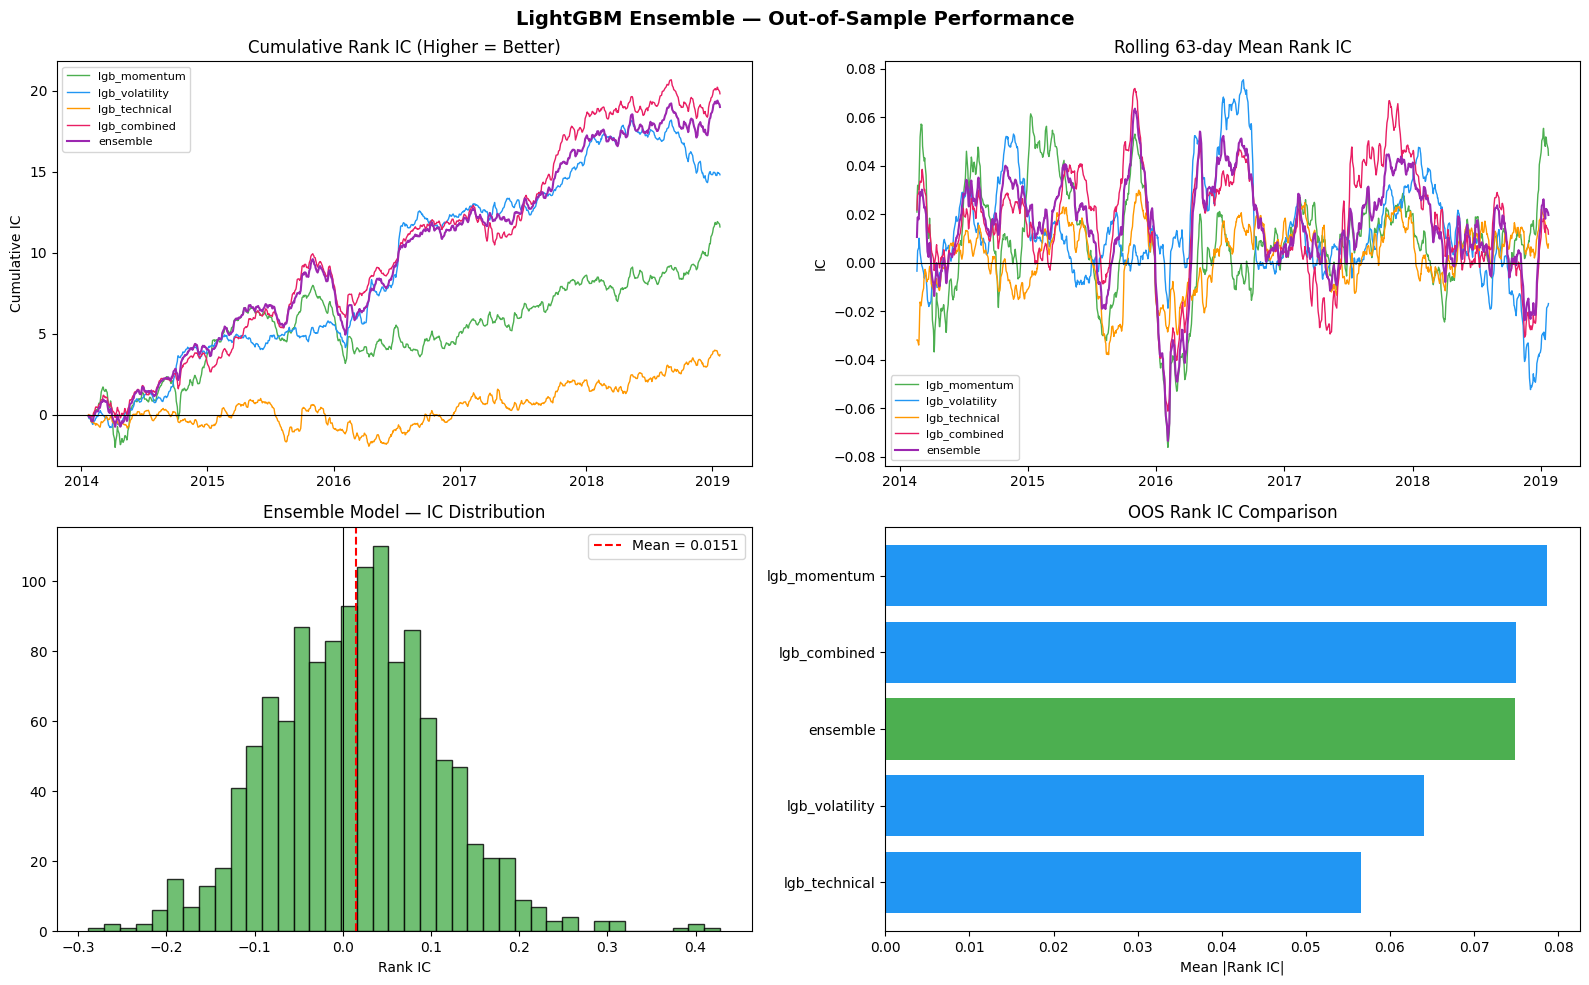

In [10]:
# ── Rank IC Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

palette = ['#4CAF50', '#2196F3', '#FF9800', '#E91E63', '#9C27B0']

# 1. Cumulative IC
ax = axes[0, 0]
for col, color in zip(all_pred_cols, palette):
    ax.plot(ic_oos.index, ic_oos[col].cumsum(), label=col.replace('pred_', ''),
            color=color, linewidth=1.5 if col == 'pred_ensemble' else 1.0)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Cumulative Rank IC (Higher = Better)')
ax.set_ylabel('Cumulative IC')
ax.legend(fontsize=8)

# 2. Rolling 63-day mean IC
ax = axes[0, 1]
rolling_ic = ic_oos.rolling(63, min_periods=20).mean()
for col, color in zip(all_pred_cols, palette):
    ax.plot(rolling_ic.index, rolling_ic[col], label=col.replace('pred_', ''),
            color=color, linewidth=1.5 if col == 'pred_ensemble' else 1.0)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Rolling 63-day Mean Rank IC')
ax.set_ylabel('IC')
ax.legend(fontsize=8)

# 3. IC Distribution (ensemble)
ax = axes[1, 0]
ax.hist(ic_oos['pred_ensemble'].dropna(), bins=40, color='#4CAF50', edgecolor='black', alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(ic_oos['pred_ensemble'].mean(), color='red', linestyle='--',
           label=f'Mean = {ic_oos["pred_ensemble"].mean():.4f}')
ax.set_title('Ensemble Model — IC Distribution')
ax.set_xlabel('Rank IC')
ax.legend()

# 4. Model comparison bar chart
ax = axes[1, 1]
ic_means = ic_oos_summary['|Mean IC|'].sort_values(ascending=True)
ax.barh(range(len(ic_means)), ic_means.values,
        color=['#4CAF50' if col == 'pred_ensemble' else '#2196F3' for col in ic_means.index])
ax.set_yticks(range(len(ic_means)))
ax.set_yticklabels([c.replace('pred_', '') for c in ic_means.index])
ax.set_xlabel('Mean |Rank IC|')
ax.set_title('OOS Rank IC Comparison')

plt.suptitle('LightGBM Ensemble — Out-of-Sample Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(WD / 'alpha_ic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Long-Short Backtest (Signal → Returns)

In [11]:
def long_short_backtest(
    oos_df:  pd.DataFrame,
    pred_col: str = 'pred_ensemble',
    top_n:    int = TOP_N,
    bottom_n: int = BOTTOM_N,
    tc_bps:   float = TC_BPS
) -> pd.DataFrame:
    """
    Simulate a daily-rebalanced long-short strategy:
      - Long: top_n stocks by predicted rank
      - Short: bottom_n stocks by predicted rank
    Apply transaction cost on each rebalance.
    Returns daily portfolio returns.
    """
    daily_rets = []

    prev_long  = set()
    prev_short = set()

    for dt, group in oos_df.groupby('date'):
        sub = group[['ticker', pred_col, 'fwd_ret_5d']].dropna()
        if len(sub) < top_n + bottom_n:
            continue

        sub = sub.sort_values(pred_col, ascending=False)
        long_tickers  = set(sub.head(top_n)['ticker'])
        short_tickers = set(sub.tail(bottom_n)['ticker'])

        # Average 5-day forward return for each leg
        long_ret  = sub[sub['ticker'].isin(long_tickers)]['fwd_ret_5d'].mean()
        short_ret = sub[sub['ticker'].isin(short_tickers)]['fwd_ret_5d'].mean()
        ls_ret    = long_ret - short_ret  # long-short return

        # Transaction cost: number of new positions × (tc_bps / 10000)
        turnover_long  = len(long_tickers  - prev_long)  / max(top_n, 1)
        turnover_short = len(short_tickers - prev_short) / max(bottom_n, 1)
        tc = (turnover_long + turnover_short) * (tc_bps / 10000)

        daily_rets.append({
            'date':       dt,
            'long_ret':   long_ret,
            'short_ret':  short_ret,
            'ls_ret':     ls_ret - tc,
            'tc':         tc,
            'gross_ret':  ls_ret
        })
        prev_long  = long_tickers
        prev_short = short_tickers

    return pd.DataFrame(daily_rets).set_index('date')


bt_results = {}
for pred_col in all_pred_cols:
    bt_results[pred_col] = long_short_backtest(oos_df, pred_col=pred_col)

print('Backtest simulations complete ✓')

Backtest simulations complete ✓


In [12]:
def compute_performance_metrics(ret_series: pd.Series, freq_per_year: int = 252) -> dict:
    """Compute institutional-grade performance metrics."""
    ret = ret_series.dropna()
    if len(ret) == 0:
        return {}

    ann_ret    = ret.mean() * freq_per_year
    ann_vol    = ret.std()  * np.sqrt(freq_per_year)
    sharpe     = ann_ret / ann_vol if ann_vol > 0 else 0

    downside   = ret[ret < 0].std() * np.sqrt(freq_per_year)
    sortino    = ann_ret / downside if downside > 0 else 0

    cumret     = (1 + ret).cumprod()
    running_max = cumret.cummax()
    drawdown   = (cumret - running_max) / running_max
    max_dd     = drawdown.min()

    calmar     = ann_ret / (-max_dd) if max_dd < 0 else 0

    win_rate   = (ret > 0).mean()

    gains      = ret[ret > 0].sum()
    losses     = ret[ret < 0].abs().sum()
    pf         = gains / losses if losses > 0 else np.inf

    var95      = ret.quantile(0.05)
    cvar95     = ret[ret <= var95].mean()

    return {
        'Annual Return':   f'{ann_ret*100:.2f}%',
        'Annual Volatility': f'{ann_vol*100:.2f}%',
        'Sharpe Ratio':    f'{sharpe:.3f}',
        'Sortino Ratio':   f'{sortino:.3f}',
        'Max Drawdown':    f'{max_dd*100:.2f}%',
        'Calmar Ratio':    f'{calmar:.3f}',
        'Win Rate':        f'{win_rate*100:.1f}%',
        'Profit Factor':   f'{pf:.3f}',
        'VaR (95%)':       f'{var95*100:.3f}%',
        'CVaR (95%)':      f'{cvar95*100:.3f}%',
    }


print('='*80)
print('LONG-SHORT PORTFOLIO PERFORMANCE (after transaction costs)')
print('='*80)
for model_name, bt_df in bt_results.items():
    metrics = compute_performance_metrics(bt_df['ls_ret'])
    print(f'\n{model_name.upper()}')
    for k, v in metrics.items():
        print(f'  {k:<25}: {v}')

LONG-SHORT PORTFOLIO PERFORMANCE (after transaction costs)

PRED_LGB_MOMENTUM
  Annual Return            : 18.44%
  Annual Volatility        : 29.42%
  Sharpe Ratio             : 0.627
  Sortino Ratio            : 0.913
  Max Drawdown             : -64.50%
  Calmar Ratio             : 0.286
  Win Rate                 : 53.3%
  Profit Factor            : 1.112
  VaR (95%)                : -2.826%
  CVaR (95%)               : -4.181%

PRED_LGB_VOLATILITY
  Annual Return            : 15.27%
  Annual Volatility        : 25.66%
  Sharpe Ratio             : 0.595
  Sortino Ratio            : 0.921
  Max Drawdown             : -55.07%
  Calmar Ratio             : 0.277
  Win Rate                 : 51.0%
  Profit Factor            : 1.109
  VaR (95%)                : -2.492%
  CVaR (95%)               : -3.511%

PRED_LGB_TECHNICAL
  Annual Return            : -5.05%
  Annual Volatility        : 21.04%
  Sharpe Ratio             : -0.240
  Sortino Ratio            : -0.389
  Max Drawdown       

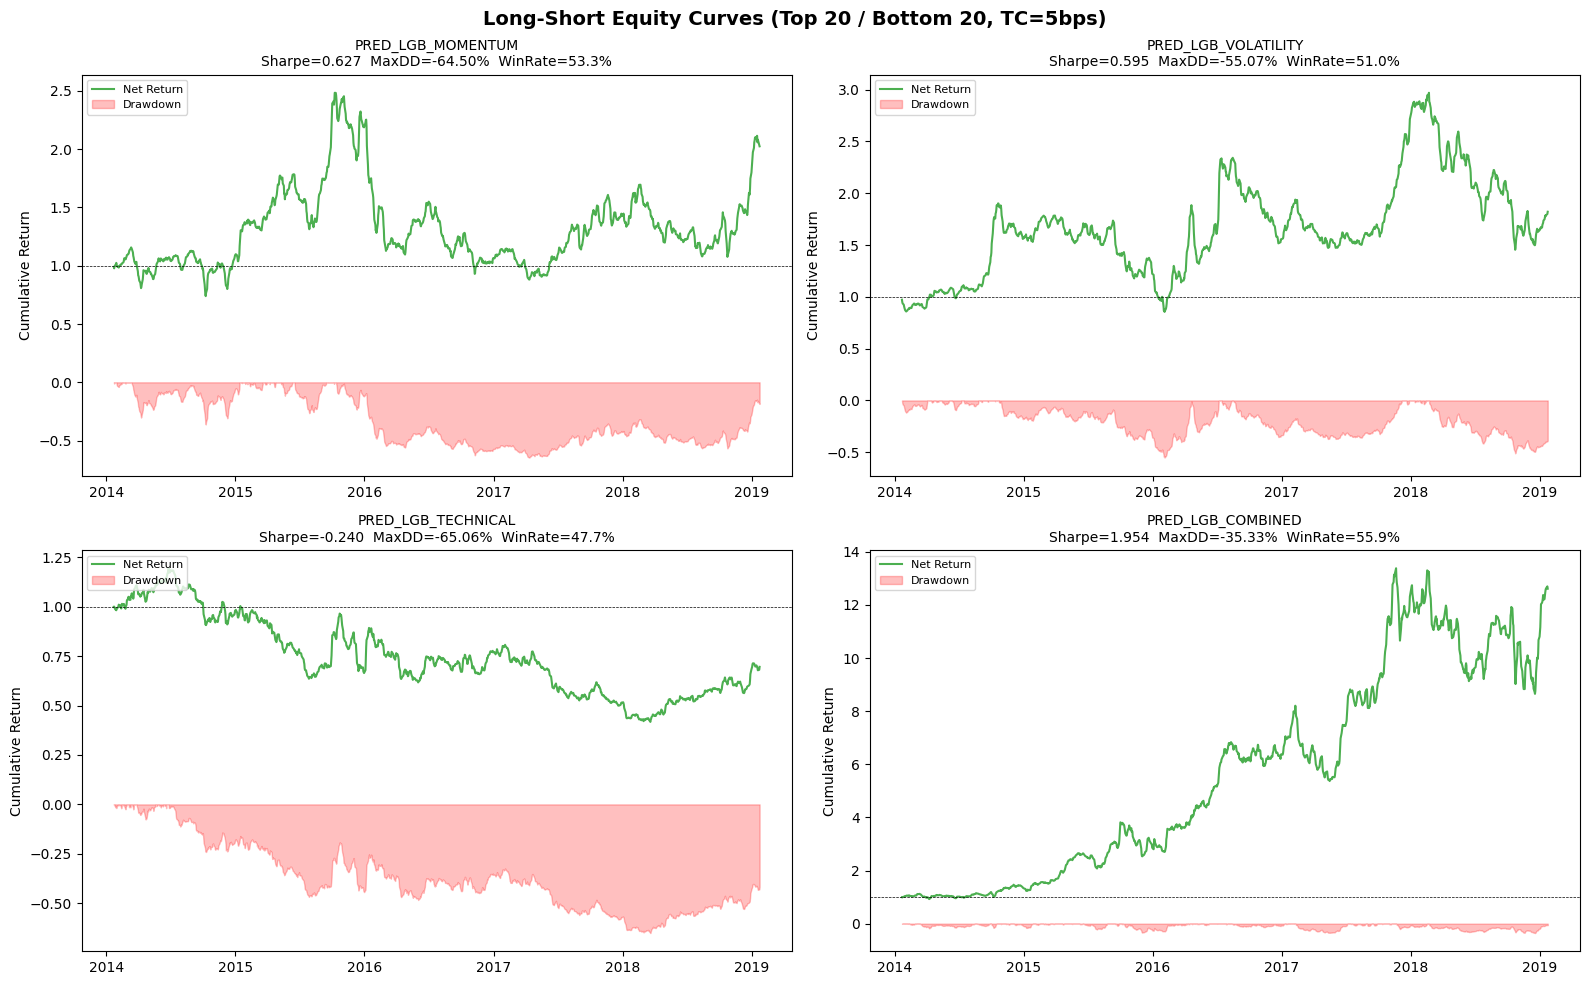

In [13]:
# ── Equity Curves ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (pred_col, bt_df) in zip(axes, bt_results.items()):
    cumret    = (1 + bt_df['ls_ret']).cumprod()
    running_max = cumret.cummax()
    drawdown  = (cumret - running_max) / running_max

    color = '#4CAF50'
    ax.plot(cumret.index, cumret.values, color=color, linewidth=1.5, label='Net Return')
    ax.fill_between(drawdown.index, drawdown.values, 0, alpha=0.25, color='red', label='Drawdown')
    ax.axhline(1, color='black', linewidth=0.5, linestyle='--')

    metrics = compute_performance_metrics(bt_df['ls_ret'])
    subtitle = f"Sharpe={metrics['Sharpe Ratio']}  MaxDD={metrics['Max Drawdown']}  WinRate={metrics['Win Rate']}"
    ax.set_title(f'{pred_col.upper()}\n{subtitle}', fontsize=10)
    ax.set_ylabel('Cumulative Return')
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle(f'Long-Short Equity Curves (Top {TOP_N} / Bottom {BOTTOM_N}, TC={TC_BPS}bps)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(WD / 'equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 — SHAP Feature Importance (Interpretability)

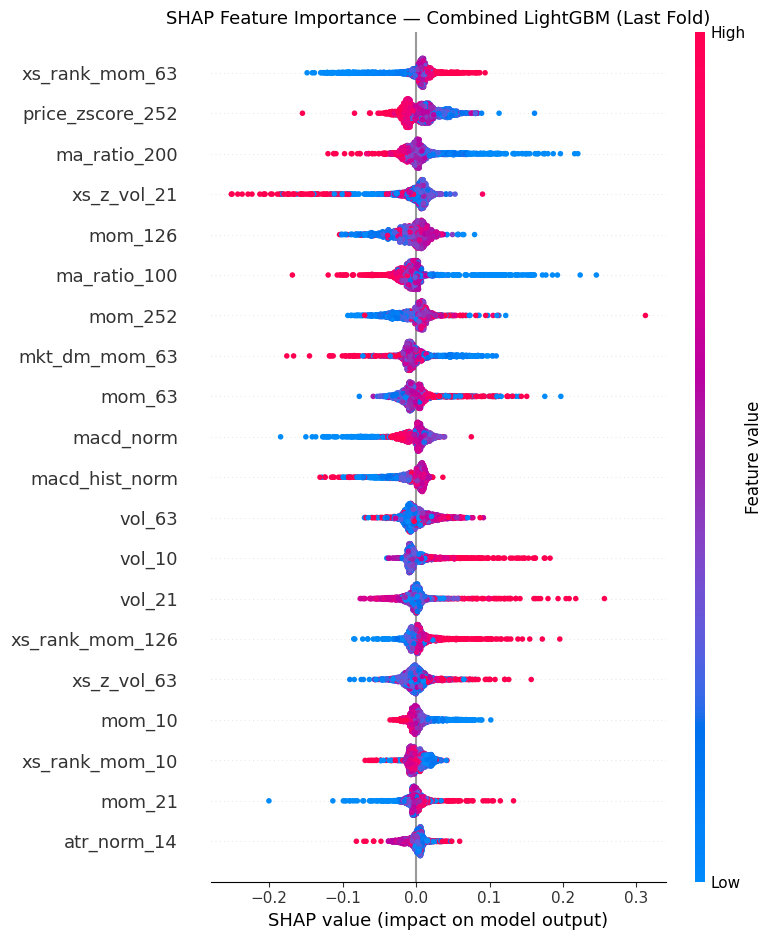

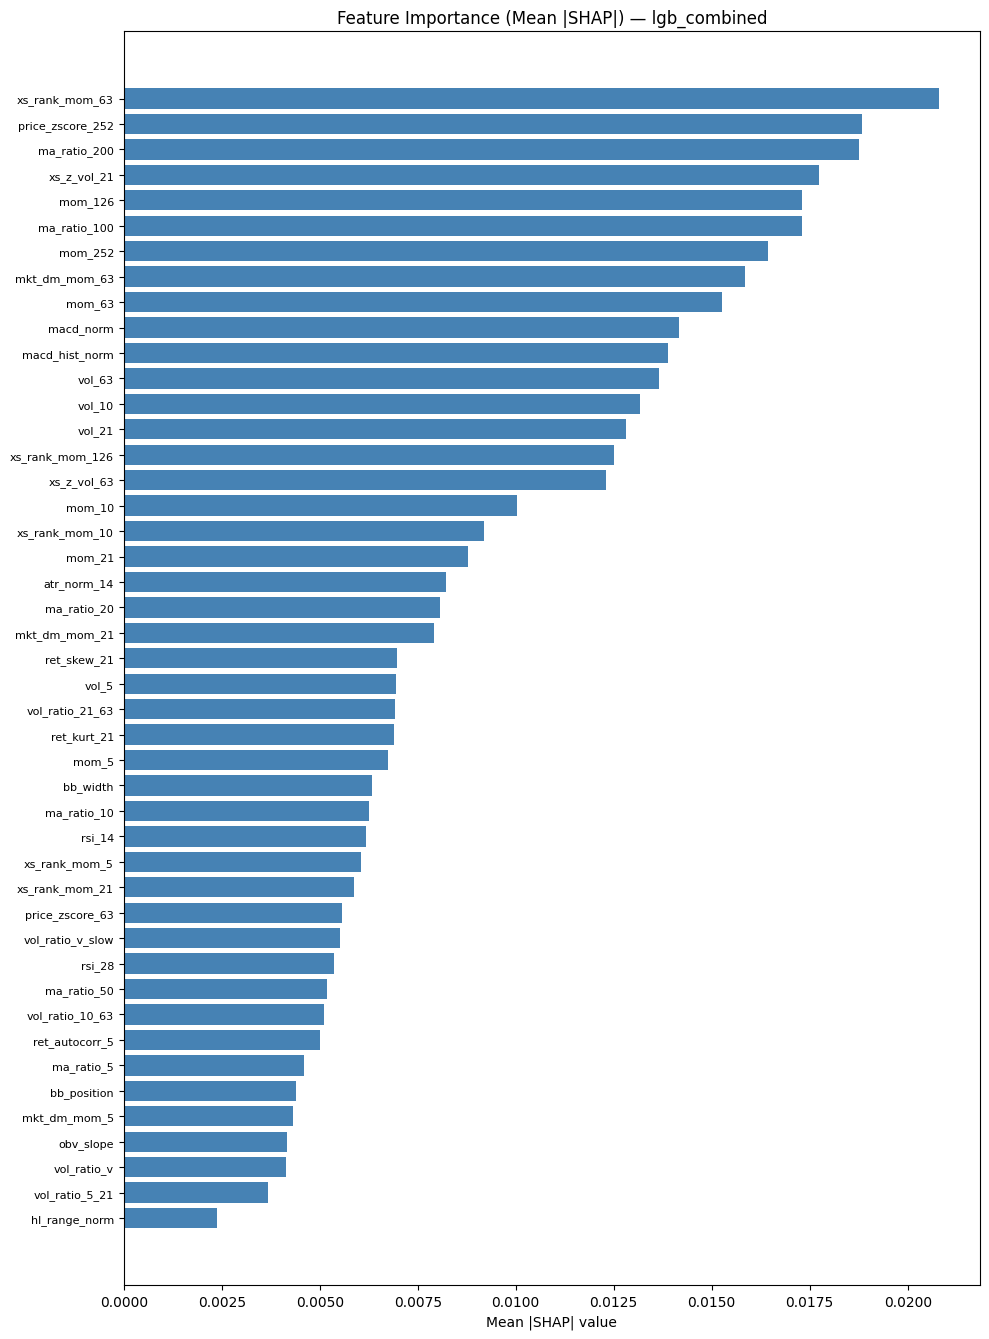

In [14]:
# ── SHAP for the combined model (last fold) ───────────────────────────────────
combined_model = fold_models[len(folds_to_use)]['lgb_combined']

# Sample 2000 rows for SHAP (full dataset can be slow)
last_fold_ts, last_fold_te, last_vs, last_ve = folds_to_use[-1]
test_mask = (panel['date'] >= last_vs) & (panel['date'] <= last_ve)
test_sample = panel[test_mask].dropna(subset=SELECTED_FEATS).sample(
    min(2000, test_mask.sum()), random_state=42
)
X_test = test_sample[SELECTED_FEATS].values.astype(np.float32)

explainer    = shap.TreeExplainer(combined_model)
shap_values  = explainer.shap_values(X_test)

# Summary beeswarm plot
plt.figure(figsize=(12, max(6, len(SELECTED_FEATS) * 0.35)))
shap.summary_plot(shap_values, X_test, feature_names=SELECTED_FEATS, show=False)
plt.title('SHAP Feature Importance — Combined LightGBM (Last Fold)', fontsize=13)
plt.tight_layout()
plt.savefig(WD / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart of mean |SHAP|
mean_abs_shap = np.abs(shap_values).mean(0)
shap_importance = pd.Series(mean_abs_shap, index=SELECTED_FEATS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(SELECTED_FEATS) * 0.3)))
ax.barh(range(len(shap_importance)), shap_importance.values, color='steelblue')
ax.set_yticks(range(len(shap_importance)))
ax.set_yticklabels(shap_importance.index, fontsize=8)
ax.set_xlabel('Mean |SHAP| value')
ax.set_title('Feature Importance (Mean |SHAP|) — lgb_combined')
plt.tight_layout()
plt.savefig(WD / 'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 — Decile Return Analysis (Quintile Spread)

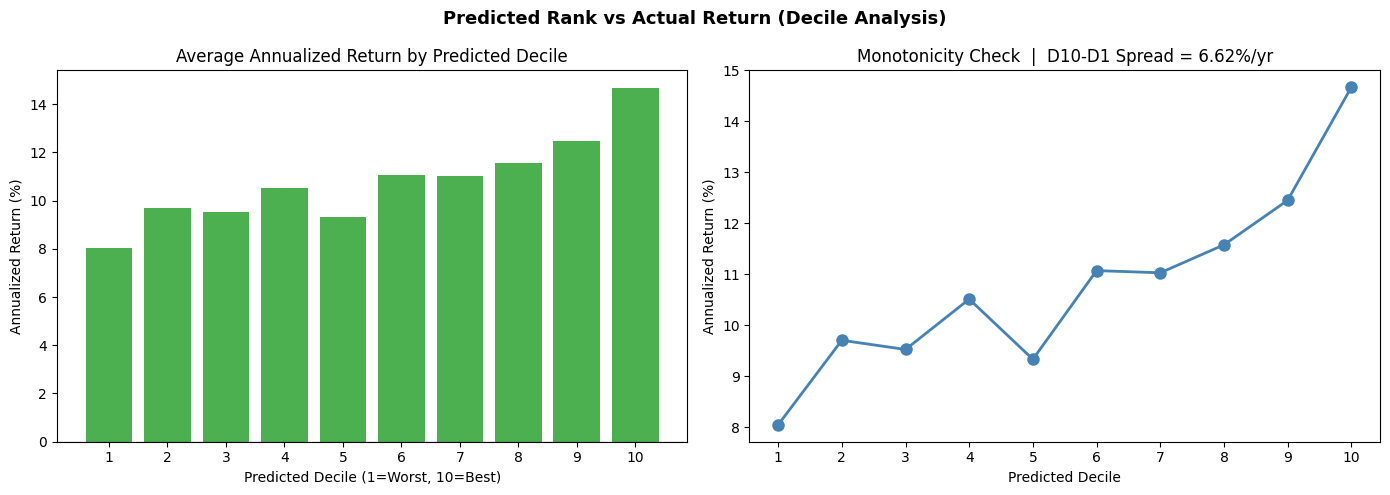

             avg_fwd_ret_5d    median  volatility  count  annualized_return
pred_decile                                                                
1                  0.001597  0.002645    0.038808  61212           0.080509
2                  0.001926  0.003202    0.034451  60727           0.097086
3                  0.001891  0.003280    0.034019  60387           0.095283
4                  0.002086  0.003430    0.034027  60685           0.105151
5                  0.001852  0.003402    0.033899  60769           0.093363
6                  0.002197  0.003392    0.034032  60449           0.110745
7                  0.002189  0.003594    0.034666  60543           0.110318
8                  0.002298  0.003614    0.035301  60529           0.115798
9                  0.002471  0.003718    0.036979  60585           0.124529
10                 0.002911  0.003948    0.045766  60992           0.146697


In [15]:
# ── Decile return analysis: do predicted top-decile stocks actually outperform?
oos_df['pred_decile'] = oos_df.groupby('date')['pred_ensemble'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1
)

decile_returns = (
    oos_df.groupby('pred_decile')['fwd_ret_5d']
          .agg(['mean', 'median', 'std', 'count'])
          .rename(columns={'mean': 'avg_fwd_ret_5d', 'std': 'volatility'})
)
decile_returns['annualized_return'] = decile_returns['avg_fwd_ret_5d'] * 252 / 5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean return per decile
colors = ['#f44336' if v < 0 else '#4CAF50' for v in decile_returns['avg_fwd_ret_5d'].values]
axes[0].bar(decile_returns.index, decile_returns['annualized_return'] * 100, color=colors)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Predicted Decile (1=Worst, 10=Best)')
axes[0].set_ylabel('Annualized Return (%)')
axes[0].set_title('Average Annualized Return by Predicted Decile')
axes[0].set_xticks(range(1, 11))

# Monotonicity check: should be increasing
spread = decile_returns['avg_fwd_ret_5d'].iloc[-1] - decile_returns['avg_fwd_ret_5d'].iloc[0]
axes[1].plot(decile_returns.index, decile_returns['avg_fwd_ret_5d'] * 252 / 5 * 100,
             'o-', color='steelblue', linewidth=2, markersize=8)
axes[1].set_xlabel('Predicted Decile')
axes[1].set_ylabel('Annualized Return (%)')
axes[1].set_title(f'Monotonicity Check  |  D10-D1 Spread = {spread*252/5*100:.2f}%/yr')
axes[1].set_xticks(range(1, 11))

plt.suptitle('Predicted Rank vs Actual Return (Decile Analysis)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(WD / 'decile_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(decile_returns.to_string())

## 8 — Save Models & Results

In [16]:
# Save the last-fold models (most recent = most relevant for deployment)
last_fold = len(folds_to_use)
for model_name, model in fold_models[last_fold].items():
    model_path = WD / f'model_{model_name}.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f'Saved {model_path}')

# Save hyperparameter history
with open(WD / 'fold_params.json', 'w') as f:
    # Convert to JSON-serializable format
    json_safe = {
        str(fold): {
            name: {k: float(v) if isinstance(v, (np.float32, np.float64)) else v
                   for k, v in params.items()}
            for name, params in models.items()
        }
        for fold, models in fold_params.items()
    }
    json.dump(json_safe, f, indent=2)
print('Saved fold_params.json')

# Save OOS predictions
oos_df.to_parquet(WD / 'oos_predictions.parquet', index=False)
print('Saved oos_predictions.parquet')

# Save performance summary as CSV
perf_rows = []
for pred_col, bt_df in bt_results.items():
    m = compute_performance_metrics(bt_df['ls_ret'])
    m['model'] = pred_col
    perf_rows.append(m)
pd.DataFrame(perf_rows).set_index('model').to_csv(WD / 'alpha_model_performance.csv')
print('Saved alpha_model_performance.csv')

# Model registry entry
registry_entry = {
    'timestamp':       pd.Timestamp.now().isoformat(),
    'model_version':   '02-alpha-lgb-ensemble-v1',
    'features_used':   SELECTED_FEATS,
    'n_folds':         len(folds_to_use),
    'train_years':     TRAIN_YEARS,
    'test_years':      TEST_YEARS,
    'embargo_days':    EMBARGO_DAYS,
    'optuna_trials':   OPTUNA_TRIALS,
    'ensemble_sharpe': float(bt_results['pred_ensemble']['ls_ret'].mean() * 252 /
                             (bt_results['pred_ensemble']['ls_ret'].std() * np.sqrt(252) + 1e-9)),
    'feature_groups':  {k: len(v) for k, v in FEATURE_GROUPS.items()}
}
with open(WD / 'model_registry.json', 'w') as f:
    json.dump(registry_entry, f, indent=2)
print('Saved model_registry.json')
print('\n✓ Alpha Models — All outputs saved')

Saved model_lgb_momentum.pkl
Saved model_lgb_volatility.pkl
Saved model_lgb_technical.pkl
Saved model_lgb_combined.pkl
Saved fold_params.json
Saved oos_predictions.parquet
Saved alpha_model_performance.csv
Saved model_registry.json

✓ Alpha Models — All outputs saved
